# load data

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("Train.csv")
print(df.head())
df.info()

   Post ID Subreddit                                         Post Title  \
0  1h7hvjd     memes                               It’s a full time job   
1  1h7hqx1     memes          Maybe we do need the Bible in schools lol   
2  1h7hpdm     memes                                           Sad Guts   
3  1h7hksk     memes                                           Sad Hulk   
4  1h7hiw6     memes  Hey, neck-bearded fedora-wearers. These memes ...   

   Upvotes  Downvotes  Score  Upvote Ratio             Author  \
0        1          0      1          1.00    onegonethusband   
1        4          0      4          1.00       DrizzleDrain   
2        0          0      0          0.50             urzaga   
3        6          0      6          0.88  Clear-Example3029   
4        2          0      2          0.63        AverageSign   

             Post Time  Number of Comments  ...  First Hour Upvotes viral  \
0  2024-12-05 19:44:21                   0  ...                 1.0     0   
1  2

In [2]:
# -----------------------------------
# DUPLICATE CHECK
# -----------------------------------

# Find all rows involved in duplicate Post IDs
duplicate_rows = (
    df[df["Post ID"].duplicated(keep=False)]
    .sort_values("Post ID")
)

print(f"Duplicate rows found: {len(duplicate_rows)}")
print(
    f"Duplicate Post IDs found: "
    f"{duplicate_rows['Post ID'].nunique()}"
)

# Show first few duplicate records
print("\nSample duplicate rows:")
display(duplicate_rows.head())

# -----------------------------------
# RECORD REMOVED OBSERVATIONS
# -----------------------------------

# Rows that will be removed
removed_duplicates = (
    df[df["Post ID"].duplicated(keep="first")]
    .sort_values("Post ID")
)

print(
    f"\nRows that will be removed: "
    f"{len(removed_duplicates)}"
)

# Save for audit trail
removed_duplicates.to_csv(
    "removed_duplicate_posts.csv",
    index=False
)

# -----------------------------------
# REMOVE DUPLICATES
# -----------------------------------

original_n = len(df)

df = (
    df.drop_duplicates(
        subset=["Post ID"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    f"\nRows before deduplication: {original_n}"
)
print(
    f"Rows after deduplication: {len(df)}"
)
print(
    f"Rows removed: {original_n - len(df)}"
)

# -----------------------------------
# VERIFY
# -----------------------------------

remaining_duplicates = (
    df["Post ID"]
    .duplicated()
    .sum()
)

print(
    f"\nRemaining duplicate Post IDs: "
    f"{remaining_duplicates}"
)

# Show cleaned dataframe
display(df.head())

Duplicate rows found: 264
Duplicate Post IDs found: 132

Sample duplicate rows:


,Post ID,Subreddit,Post Title,Upvotes,Downvotes,Score,Upvote Ratio,Author,Post Time,Number of Comments,...,First Hour Upvotes,viral,title_length,title_sentiment,hour,day,weekday,month,year,category_encoded
23842,1g7f4z6,Space,"Brasília at night, captured from Space Station...",1986,0,1986,0.97,astro_pettit,2024-10-19 18:20:01,38,...,NaN,0,73,0.50,18,19,5,10,2024,1
26579,1g7f4z6,space,"Brasília at night, captured from Space Station...",1988,0,1988,0.97,astro_pettit,2024-10-19 18:20:01,38,...,NaN,0,73,0.50,18,19,5,10,2024,4
26578,1g7n60i,space,The Eye of God: A Stunning Deep Space Nebula C...,15013,0,15013,0.97,NightSkyCamera,2024-10-20 00:51:16,171,...,NaN,1,72,0.25,0,20,6,10,2024,4
23841,1g7n60i,Space,The Eye of God: A Stunning Deep Space Nebula C...,15009,0,15009,0.97,NightSkyCamera,2024-10-20 00:51:16,171,...,NaN,1,72,0.25,0,20,6,10,2024,1
23840,1g7rezj,Space,Northern Lights in Canada on the 10th,724,0,724,0.97,weathercat4,2024-10-20 05:08:08,4,...,NaN,0,37,0.00,5,20,6,10,2024,1



Rows that will be removed: 132

Rows before deduplication: 27587
Rows after deduplication: 27455
Rows removed: 132

Remaining duplicate Post IDs: 0


,Post ID,Subreddit,Post Title,Upvotes,Downvotes,Score,Upvote Ratio,Author,Post Time,Number of Comments,...,First Hour Upvotes,viral,title_length,title_sentiment,hour,day,weekday,month,year,category_encoded
0,1h7hvjd,memes,It’s a full time job,1,0,1,1.00,onegonethusband,2024-12-05 19:44:21,0,...,1.0,0,20,0.35,19,5,3,12,2024,3
1,1h7hqx1,memes,Maybe we do need the Bible in schools lol,4,0,4,1.00,DrizzleDrain,2024-12-05 19:38:53,1,...,4.0,0,41,0.80,19,5,3,12,2024,3
2,1h7hpdm,memes,Sad Guts,0,0,0,0.50,urzaga,2024-12-05 19:37:07,0,...,0.0,0,8,-0.50,19,5,3,12,2024,3
3,1h7hksk,memes,Sad Hulk,6,0,6,0.88,Clear-Example3029,2024-12-05 19:31:51,1,...,6.0,0,8,-0.50,19,5,3,12,2024,3
4,1h7hiw6,memes,"Hey, neck-bearded fedora-wearers. These memes ...",2,0,2,0.63,AverageSign,2024-12-05 19:29:40,1,...,2.0,0,93,0.00,19,5,3,12,2024,3


# **exploring text embedding**

In [ ]:
import re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

# -----------------------------------
# CLEAN TITLES
# -----------------------------------

df["clean_title"] = (
    df["Post Title"]
    .fillna("")
    .str.lower()
    .apply(lambda x: re.sub(r"http\S+", "", x))          # remove URLs
    .apply(lambda x: re.sub(r"[^a-z0-9\s]", " ", x))     # remove punctuation
    .apply(lambda x: re.sub(r"\s+", " ", x).strip())     # collapse spaces
)

# -----------------------------------
# LOAD MODEL
# -----------------------------------

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

# -----------------------------------
# EMBED TITLES
# -----------------------------------

title_embeddings = model.encode(
    df["clean_title"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

# -----------------------------------
# SAVE
# -----------------------------------

title_df = pd.DataFrame(
    title_embeddings,
    columns=[
        f"title_emb_{i}"
        for i in range(title_embeddings.shape[1])
    ]
)

title_df["Post ID"] = df["Post ID"].values

title_df.to_parquet(
    "reddit_title_embeddings.parquet",
    index=False
)

print(title_df.head())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/429 [00:00<?, ?it/s]

   title_emb_0  title_emb_1  title_emb_2  title_emb_3  title_emb_4  \
0    -0.037496     0.031005     0.064867     0.017243     0.003036   
1    -0.013536     0.094918     0.064510    -0.019695     0.028058   
2     0.060418     0.042148     0.055410     0.021795     0.005462   
3    -0.002342     0.085494    -0.024161     0.029496     0.025046   
4    -0.035601     0.006854     0.112918    -0.026804     0.066346   

   title_emb_5  title_emb_6  title_emb_7  title_emb_8  title_emb_9  ...  \
0    -0.057989     0.027962    -0.065370    -0.053345     0.017059  ...   
1     0.025534    -0.042252    -0.018830     0.156609     0.085228  ...   
2    -0.063075    -0.014238     0.036499     0.044910    -0.097596  ...   
3     0.045831     0.040994     0.091328    -0.017336    -0.039256  ...   
4    -0.056677     0.017498    -0.031110     0.004837     0.035067  ...   

   title_emb_375  title_emb_376  title_emb_377  title_emb_378  title_emb_379  \
0      -0.005648       0.049703      -0.014777  

# **exploring image embedding**

In [45]:
image_urls = df[["Image URL"]]
image_urls

,Image URL
0,https://i.redd.it/awredc20335e1.jpeg
1,https://i.redd.it/6fqobdy0235e1.jpeg
2,https://i.redd.it/3uepc8jp135e1.jpeg
3,https://i.redd.it/hmhtrwqr035e1.jpeg
4,https://i.redd.it/4hn5lwsd035e1.jpeg
...,...
27450,https://i.redd.it/7utml4bhmzqd1.jpeg
27451,https://i.redd.it/3qve2pbq8tqd1.jpeg
27452,https://i.redd.it/q3xnnv6mosqd1.png
27453,https://i.redd.it/1ksj2ucdv9qd1.png


In [4]:
# we are considering generating CLIP embeddings in order to use the image data in our ensemble model.
# to do so we first need to check how many image URLs can actually be found now, because this dataset was collected quite awhile ago;
# some posts may have been deleted or modified since then.

import pandas as pd
import requests
import random
from tqdm import tqdm

sample_size = 300

sample_urls = (
    df["Image URL"]
    .dropna()
    .sample(sample_size, random_state=42)
)

survived = 0

for url in tqdm(sample_urls):
    try:
        r = requests.head(
            url,
            allow_redirects=True,
            timeout=5
        )

        if r.status_code == 200:
            survived += 1

    except:
        pass

survival_rate = survived / sample_size

print(f"Survival rate: {survival_rate:.2%}")

100%|██████████| 300/300 [01:37<00:00,  3.08it/s]

Survival rate: 92.67%


in a random check of 300 of the URLs provided, we find that more than 90% still remain. data might still be usable!

In [48]:
START_ROW = 13400
CHUNK_DIR = "clip_chunks_run3"

sample_df = df.iloc[START_ROW:].reset_index(drop=True)
# sample_df = df.sample(n=200, random_state=42).reset_index(drop=True)

import os
import numpy as np
import pandas as pd
import requests
import torch

from io import BytesIO
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from tqdm.auto import tqdm

# -------------------------------
# CONFIG
# -------------------------------

BATCH_SIZE = 50
SAVE_EVERY = 250
session = requests.Session()

os.makedirs(CHUNK_DIR, exist_ok=True)

# -------------------------------
# CLIP
# -------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

model.eval()

# -------------------------------
# HELPERS
# -------------------------------

def download_image(url):

    try:

        r = session.get(url, timeout=10)

        if r.status_code != 200:
            return None, f"HTTP_{r.status_code}"

        if "image" not in r.headers.get(
            "Content-Type", ""
        ):
            return None, "NOT_IMAGE"

        img = Image.open(
            BytesIO(r.content)
        ).convert("RGB")

        return img, None

    except requests.Timeout:
        return None, "TIMEOUT"

    except Exception:
        return None, "OTHER"


def clip_embed(images):

    inputs = processor(
        images=images,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        features = model.get_image_features(
            **inputs
        )

        features = torch.nn.functional.normalize(
            features,
            dim=1
        )

    return features.cpu().numpy()


def save_chunk(success_ids, success_embs, chunk_num):

    if len(success_ids) == 0:
        return

    chunk_df = pd.DataFrame(
        success_embs,
        columns=[
            f"clip_{i}"
            for i in range(512)
        ]
    )

    chunk_df["Post ID"] = success_ids

    filepath = os.path.join(
        CHUNK_DIR,
        f"clip_chunk_{chunk_num}.parquet"
    )

    chunk_df.to_parquet(
        filepath,
        index=False
    )

    print(
        f"\nSaved chunk {chunk_num}: "
        f"{len(success_ids)} embeddings"
    )

# -------------------------------
# MAIN LOOP
# -------------------------------

success_ids = []
success_embs = []

failed_downloads = []
failed_embeddings = []

batch_images = []
batch_ids = []

chunk_num = 0

overall_pbar = tqdm(
    total=len(sample_df),
    desc="Processing Posts"
)

chunk_pbar = tqdm(
    total=SAVE_EVERY,
    desc=f"Chunk {chunk_num + 1}",
    leave=True
)

for _, row in sample_df.iterrows():

    post_id = row["Post ID"]
    url = row["Image URL"]

    if pd.isna(url):

        overall_pbar.update(1)
        continue

    image, reason = download_image(url)

    if image is None:

        failed_downloads.append({
            "Post ID": post_id,
            "URL": url,
            "Reason": reason
        })

        overall_pbar.update(1)

        overall_pbar.set_postfix({
            "embedded": len(success_ids),
            "failed_dl": len(failed_downloads),
            "failed_emb": len(failed_embeddings)
        })

        continue

    batch_images.append(image)
    batch_ids.append(post_id)

    if len(batch_images) >= BATCH_SIZE:

        try:

            embs = clip_embed(batch_images)

            success_ids.extend(batch_ids)
            success_embs.extend(embs)

            chunk_pbar.update(len(batch_ids))

            # save chunk when enough embeddings accumulated

            if len(success_ids) >= SAVE_EVERY:

                chunk_num += 1

                save_chunk(
                    success_ids,
                    success_embs,
                    chunk_num
                )

                success_ids.clear()
                success_embs.clear()

                chunk_pbar.close()

                chunk_pbar = tqdm(
                    total=SAVE_EVERY,
                    desc=f"Chunk {chunk_num + 1}",
                    leave=True
                )

        except Exception:

            failed_embeddings.extend(
                batch_ids
            )

        batch_images = []
        batch_ids = []

    overall_pbar.update(1)

    overall_pbar.set_postfix({
        "embedded": len(success_ids),
        "failed_dl": len(failed_downloads),
        "failed_emb": len(failed_embeddings)
    })

# -------------------------------
# FINAL PARTIAL BATCH
# -------------------------------

if batch_images:

    try:

        embs = clip_embed(batch_images)

        success_ids.extend(batch_ids)
        success_embs.extend(embs)

        chunk_pbar.update(len(batch_ids))

    except Exception:

        failed_embeddings.extend(
            batch_ids
        )

# -------------------------------
# SAVE FINAL REMAINDER
# -------------------------------

if len(success_ids) > 0:

    chunk_num += 1

    save_chunk(
        success_ids,
        success_embs,
        chunk_num
    )

# -------------------------------
# CLEAN UP PROGRESS BARS
# -------------------------------

overall_pbar.close()
chunk_pbar.close()

# -------------------------------
# SAVE FAILURES
# -------------------------------

pd.DataFrame(
    failed_downloads
).to_csv(
    "failed_downloads.csv",
    index=False
)

pd.DataFrame({
    "Post ID": failed_embeddings
}).to_csv(
    "failed_embeddings.csv",
    index=False
)

# -------------------------------
# SUMMARY
# -------------------------------

embedded_count = sum(
    len(
        pd.read_parquet(
            os.path.join(CHUNK_DIR, f)
        )
    )
    for f in os.listdir(CHUNK_DIR)
    if f.endswith(".parquet")
)

print("\n========== SUMMARY ==========")

print(
    f"Embedded: {embedded_count}"
)

print(
    f"Download failures: {len(failed_downloads)}"
)

print(
    f"Embedding failures: {len(failed_embeddings)}"
)

print(
    f"Chunks written: {chunk_num}"
)

Using device: cpu


Processing Posts:   0%|          | 0/14055 [00:00<?, ?it/s]

Chunk 1:   0%|          | 0/250 [00:00<?, ?it/s]


Saved chunk 1: 250 embeddings


Chunk 2:   0%|          | 0/250 [00:00<?, ?it/s]

...

Chunk 4:   0%|          | 0/250 [00:00<?, ?it/s]


Saved chunk 4: 250 embeddings


Chunk 5:   0%|          | 0/250 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:3368: DecompressionBombWarning: Image size (91181824 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


KeyboardInterrupt: 

In [2]:
import glob
import pandas as pd

# Parent folder containing all run folders
PARENT_FOLDER = "clip_chunk_files"

# Read every parquet file recursively
parquet_files = glob.glob(
    f"{PARENT_FOLDER}/**/*.parquet",
    recursive=True
)

# Combine all parquet files
clip_df = pd.concat(
    (pd.read_parquet(f) for f in parquet_files),
    ignore_index=True
)

# Record duplicates
duplicate_clip_embeddings = clip_df[
    clip_df.duplicated("Post ID", keep="first")
].copy()

# Remove duplicates, sort, and reset index
clip_df = (
    clip_df
    .drop_duplicates("Post ID")
    .sort_values("Post ID")
    .reset_index(drop=True)
)

# Save outputs
clip_df.to_parquet(
    "reddit_clip_embeddings.parquet",
    index=False
)

duplicate_clip_embeddings.to_csv(
    "duplicate_clip_embeddings.csv",
    index=False
)

# Summary
print(f"Parquet files read: {len(parquet_files)}")
print(f"Final embeddings: {len(clip_df)}")
print(f"Duplicates removed: {len(duplicate_clip_embeddings)}")

clip_df.to_csv(
    "reddit_clip_embeddings.csv",
    index=False
)

Parquet files read: 67
Final embeddings: 24715
Duplicates removed: 65


In [3]:
clip_df = pd.read_csv("reddit_clip_embeddings.csv")
title_df = pd.read_parquet("reddit_title_embeddings.parquet")

# join with main dataframe
df = df.merge(
    clip_df,
    on="Post ID",
    how="inner"
)

df = df.merge(
    title_df,
    on="Post ID",
    how="inner"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24715 entries, 0 to 24714
Columns: 926 entries, Post ID to title_emb_383
dtypes: float32(384), float64(516), int64(15), object(11)
memory usage: 138.4+ MB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score

import numpy as np
import pandas as pd

# --------------------------------------------------
# DATA
# --------------------------------------------------

df_model = df.copy()

drop_cols = [
    "Post ID","Subreddit","Post Title","Author",
    "Post Time","Permalink","Image URL",
    "Image Format","Image Dimensions",
    "Top Comments List","Category",

    # leakage
    "Upvotes","Downvotes","Score",
    "Upvote Ratio","Number of Comments",
    "Crossposts Count","First Hour Upvotes"
]

df_model = df_model.drop(columns=drop_cols)

clip_cols  = [c for c in df_model.columns if c.startswith("clip_")]
title_cols = [c for c in df_model.columns if c.startswith("title_emb_")]

meta_cols = [
    c for c in df_model.columns
    if c not in clip_cols + title_cols + ["viral"]
]

X_meta  = df_model[meta_cols]
X_clip  = df_model[clip_cols]
X_title = df_model[title_cols]
y = df_model["viral"]

# --------------------------------------------------
# SPLIT
# --------------------------------------------------

(
X_meta_tr, X_meta_tmp,
X_clip_tr, X_clip_tmp,
X_title_tr, X_title_tmp,
y_tr, y_tmp
) = train_test_split(
    X_meta, X_clip, X_title, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

(
X_meta_val, X_meta_te,
X_clip_val, X_clip_te,
X_title_val, X_title_te,
y_val, y_te
) = train_test_split(
    X_meta_tmp,
    X_clip_tmp,
    X_title_tmp,
    y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=42
)

# --------------------------------------------------
# BASE MODELS
# --------------------------------------------------

# xgboost model
from xgboost import XGBClassifier

meta_model = make_pipeline(
    SimpleImputer(strategy="median"),
    XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
)

# # random forest model
# from sklearn.ensemble import RandomForestClassifier

# meta_model = make_pipeline(
#     SimpleImputer(strategy="median"),
#     RandomForestClassifier(
#         n_estimators=300,
#         class_weight="balanced",
#         random_state=42,
#         n_jobs=-1
#     )
# )

clip_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    )
)

title_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    )
)

meta_model.fit(X_meta_tr, y_tr)
clip_model.fit(X_clip_tr, y_tr)
title_model.fit(X_title_tr, y_tr)

# --------------------------------------------------
# STACKING FEATURES
# --------------------------------------------------

def stack(meta, clip, title):
    return pd.DataFrame({
        "meta":  meta_model.predict_proba(meta)[:,1],
        "clip":  clip_model.predict_proba(clip)[:,1],
        "title": title_model.predict_proba(title)[:,1]
    })

train_stack = stack(X_meta_tr, X_clip_tr, X_title_tr)
val_stack   = stack(X_meta_val, X_clip_val, X_title_val)
test_stack  = stack(X_meta_te, X_clip_te, X_title_te)

# --------------------------------------------------
# META CLASSIFIER
# --------------------------------------------------

ensemble = LogisticRegression(
    class_weight="balanced"
)

ensemble.fit(train_stack, y_tr)

# --------------------------------------------------
# THRESHOLD TUNING
# --------------------------------------------------

val_prob = ensemble.predict_proba(val_stack)[:,1]

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.05,0.96,0.01):

    pred = (val_prob >= t).astype(int)

    f1 = f1_score(y_val, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best threshold: {best_thresh:.2f}")
print(f"Validation F1: {best_f1:.3f}")

# --------------------------------------------------
# TEST
# --------------------------------------------------

prob = ensemble.predict_proba(test_stack)[:,1]
pred = (prob >= best_thresh).astype(int)

print("\n===== TEST RESULTS =====")
print(classification_report(y_te, pred))
print("ROC-AUC:", roc_auc_score(y_te, prob))

Best threshold: 0.60
Validation F1: 0.464

===== TEST RESULTS =====
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      3224
           1       0.42      0.51      0.46       484

    accuracy                           0.84      3708
   macro avg       0.67      0.70      0.68      3708
weighted avg       0.86      0.84      0.85      3708

ROC-AUC: 0.8402554190677357


In [15]:
"""
the above chunk of code uses the validation set to determine the final threshold rate. 
what if, instead, we use the validation set to determine the best combination of weights for the three base models?
this would likely give us a more informed model, as we would know which set of weights is optimal for the validation set, and we can then use those weights to make predictions on the test set.

this chunk of code tries to check for the best combination of weights for the learner.
"""

from sklearn.metrics import f1_score
import numpy as np

# --------------------------------------------------
# Probabilities from base models
# --------------------------------------------------

meta_train = meta_model.predict_proba(X_meta_tr)[:,1]
clip_train = clip_model.predict_proba(X_clip_tr)[:,1]
title_train = title_model.predict_proba(X_title_tr)[:,1]

meta_val = meta_model.predict_proba(X_meta_val)[:,1]
clip_val = clip_model.predict_proba(X_clip_val)[:,1]
title_val = title_model.predict_proba(X_title_val)[:,1]

meta_test = meta_model.predict_proba(X_meta_te)[:,1]
clip_test = clip_model.predict_proba(X_clip_te)[:,1]
title_test = title_model.predict_proba(X_title_te)[:,1]

# --------------------------------------------------
# Grid search for best ensemble weights using validation set
# --------------------------------------------------

best_f1 = 0
best_threshold = 0.5
best_weights = None

for wm in np.arange(0, 1.01, 0.01):

    for wc in np.arange(0, 1.01 - wm, 0.1):

        wt = 1 - wm - wc

        val_prob = (
            wm * meta_val +
            wc * clip_val +
            wt * title_val
        )

        for threshold in np.arange(0.05, 0.96, 0.01):

            pred = (val_prob >= threshold).astype(int)

            f1 = f1_score(y_val, pred)

            if f1 > best_f1:

                best_f1 = f1
                best_threshold = threshold
                best_weights = (wm, wc, wt)

print("\nBest ensemble weights based on validation set:")
print(f"Metadata : {best_weights[0]:.2f}")
print(f"CLIP      : {best_weights[1]:.2f}")
print(f"Title     : {best_weights[2]:.2f}")
print(f"Threshold : {best_threshold:.2f}")
print(f"Validation F1 : {best_f1:.3f}")

# --------------------------------------------------
# Final evaluation
# --------------------------------------------------

test_prob = (
    best_weights[0] * meta_test +
    best_weights[1] * clip_test +
    best_weights[2] * title_test
)

test_pred = (test_prob >= best_threshold).astype(int)

print("\n===== TEST RESULTS =====")
print(classification_report(y_te, test_pred))
print("ROC-AUC:", roc_auc_score(y_te, test_prob))


Best ensemble weights based on validation set:
Metadata : 0.56
CLIP      : 0.40
Title     : 0.04
Threshold : 0.42
Validation F1 : 0.500

===== TEST RESULTS =====
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      3224
           1       0.44      0.55      0.48       484

    accuracy                           0.85      3708
   macro avg       0.68      0.72      0.70      3708
weighted avg       0.86      0.85      0.86      3708

ROC-AUC: 0.8397619609129874


Training (70%)  
        │  
        ▼  
Train base models  
  
Validation (15%)  
        │  
        ▼  
Choose best threshold  
  
Test (15%)  
        │  
        ▼  
Final unbiased evaluation  

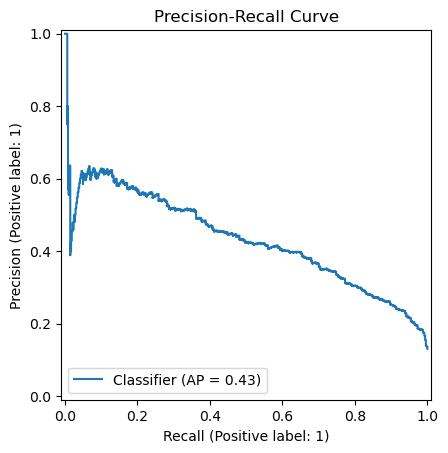

In [11]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_predictions(
    y_te,
    test_prob
)

plt.title("Precision-Recall Curve")
plt.show()

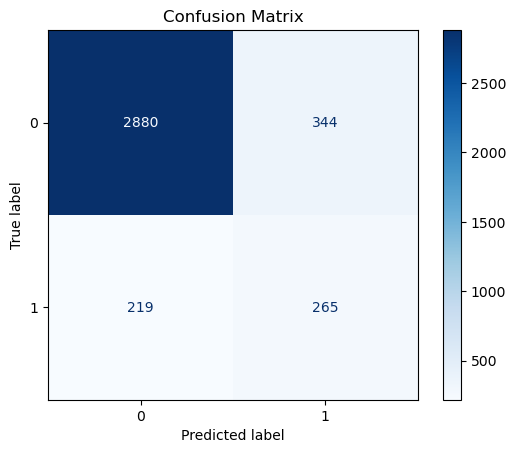

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_te,
    test_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

| **Metric**    | **Value** | **Interpretation (Viral Class)**                                                                                                                                                                                       |
| ------------- | :-------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Precision** |  **0.44** | Of all posts predicted as **viral**, **44% were actually viral**. Higher precision means fewer false positives.                                                                                                        |
| **Recall**    |  **0.55** | The model successfully identified **55% of all truly viral posts**, missing the remaining 45%. Higher recall means fewer false negatives.                                                                              |
| **F1-Score**  |  **0.48** | The harmonic mean of precision and recall, representing the model's **overall effectiveness at detecting viral posts**. Higher values indicate a better balance between finding viral posts and avoiding false alarms. |


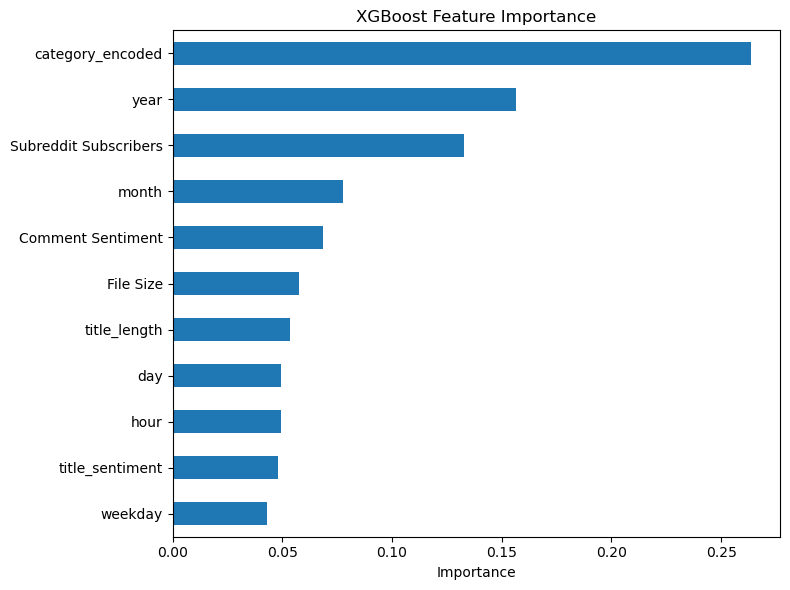

In [17]:
# # for randomforest
# import pandas as pd
# import matplotlib.pyplot as plt

# rf = meta_model.named_steps["randomforestclassifier"]

# importance = (
#     pd.Series(
#         rf.feature_importances_,
#         index=meta_cols
#     )
#     .sort_values()
# )

# importance.tail(15).plot.barh(figsize=(8,6))

# plt.title("Random Forest Feature Importance")
# plt.xlabel("Importance")
# plt.tight_layout()
# plt.show()


# for xgboost
import pandas as pd
import matplotlib.pyplot as plt

xgb = meta_model.named_steps["xgbclassifier"]

importance = (
    pd.Series(
        xgb.feature_importances_,
        index=meta_cols
    )
    .sort_values()
)

importance.tail(15).plot.barh(figsize=(8,6))

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

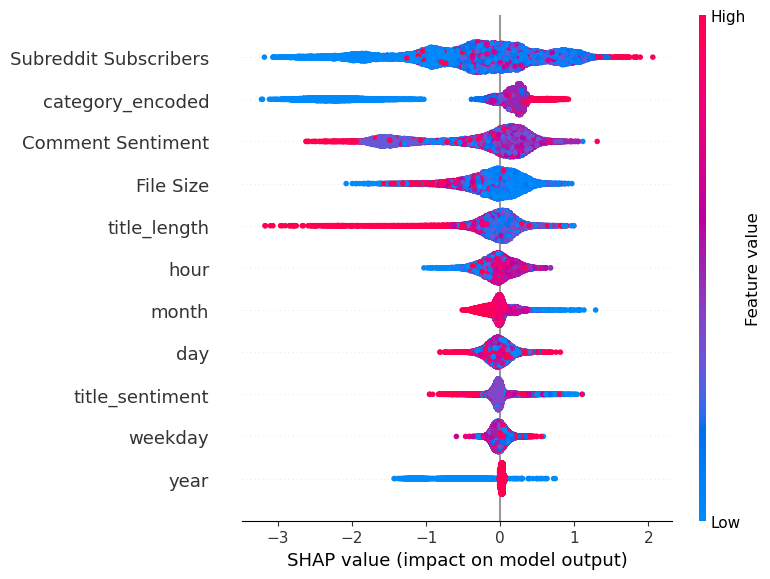

In [20]:
import shap

xgb = meta_model.named_steps["xgbclassifier"]

explainer = shap.TreeExplainer(xgb)

X_meta_imp = meta_model.named_steps["simpleimputer"].transform(X_meta)

shap_values = explainer.shap_values(X_meta_imp)

shap.summary_plot(
    shap_values,
    X_meta_imp,
    feature_names=meta_cols
)

1. category matters.
2. title length matters.
3. year matters, but in an interesting way...?

In [25]:
# obtain all unique years
df['year'].unique()

array([2024, 2023, 2022, 2021, 2018, 2020])

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


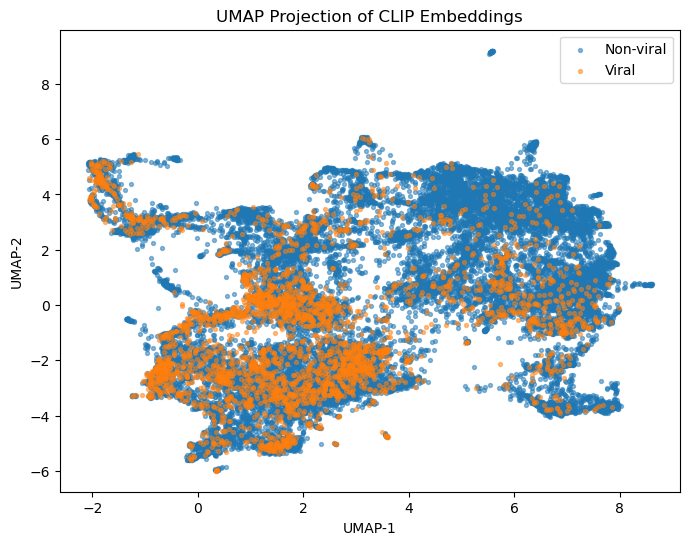

In [12]:
import umap
import matplotlib.pyplot as plt

embedding = umap.UMAP(
    random_state=42
).fit_transform(X_clip)

plt.figure(figsize=(8,6))

plt.scatter(
    embedding[y == 0, 0],
    embedding[y == 0, 1],
    s=8,
    alpha=0.5,
    label="Non-viral"
)

plt.scatter(
    embedding[y == 1, 0],
    embedding[y == 1, 1],
    s=8,
    alpha=0.5,
    label="Viral"
)

plt.title("UMAP Projection of CLIP Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()

plt.show()